<h1 style="text-align: center;">Domača naloga 3:<br/>Matematično nihalo</h1>
<p style="text-align: center;">Patrik Schembri<br/>September 2025</p>

## Uvod

Cilj naloge je napisati funkcijo, ki izračuna odmik nihala ob določenem času. Enačbo drugega prevedemo na sistem prvega reda in računamo z metodo DOPRI5,

Kotni odmik $\theta(t)$ (v radianih) pri **matematičnem nihalu** opišemo z nelinearno diferencialno enačbo:

$$
\theta''(t) + \frac{g}{l} \sin(\theta(t)) = 0, \quad \theta(0) = \theta_0, \quad \theta'(0) = \omega_0.
$$

Za **harmonično nihalo** pa imamo enačbo:

$$
\theta''(t) + \frac{g}{l} \theta(t) = 0.
$$

- Pri harmoničnem nihalu je perioda **stalna**:
$$
T = 2\pi \sqrt{\frac{l}{g}}.
$$

- Pri matematičnem nihalu pa perioda **narašča** z energijo (oziroma začetnim kotnim odmikom).

## Metode

V datoteki `Domaca03.py` smo implementirali:

- **`solve_dopri5(f, u0, tspan, h, p)`**  
  Implementacija metode Dormand–Prince RK5 (DOPRI5) za reševanje sistemov diferencialnih enačb.  
  Sprejme diferencialno funkcijo `f`, začetne pogoje `u0`, interval `tspan`, korak `h` in parametre `p`.  
  Vrne časovne točke in rešitve.

- **`nihalo(l, t, theta0, omega0, h)`**  
  Reši sistem za matematično nihalo:
  $$
  \theta'(t) = \omega(t), \quad \omega'(t) = -\tfrac{g}{l}\sin(\theta(t)).
  $$
  Vrne `θ(t)` ob času t `t`.

- **`harm_nahalo(l, t, theta0, omega0, h)`**  
  Reši sistem za harmonično (linearizirano) nihalo:
  $$
  \theta'(t) = \omega(t), \qquad \omega'(t) = -\tfrac{g}{l}\,\theta(t).
  $$
  Analitična rešitev je
  $$
  \theta(t) = \theta_0 \cos(\omega t) + \frac{\omega_0}{\omega}\sin(\omega t), \quad
  \omega = \sqrt{\tfrac{g}{l}}.
  $$
  Vrne vrednost odmika $\theta(t)$ ob času $t$.


V testih (`runtests.py`) smo pripravili še funkcije za primerjavo z **harmoničnim nihalom** in grafični prikaz rezultatov.

## Primeri uporabe

Najprej uvozimo funkcije iz naših datotek:

In [1]:
import matplotlib.pyplot as plt
from Domaca03 import nihalo
from runtests import primerjaj_nihali
import math

### Primer 1: Harmonično in matematično nihalo za majhen odmik

Pri majhnem začetnem kotu $\theta_0 = 0.1$ (to je približno 10°) se rešitvi skoraj ujemata.

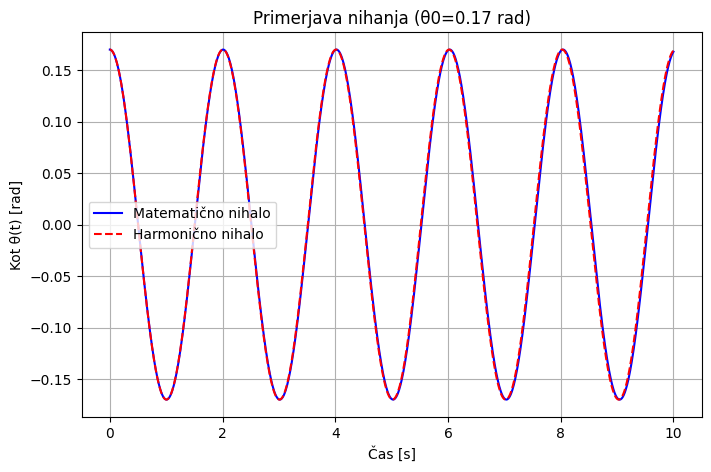

In [6]:
primerjaj_nihali(theta0=0.17, l=1.0)

### Primer 2: Večji začetni odmik

Za večji začetni kot $\theta_0 = 1.0$ (to je približno 60°) matematično nihalo zaostaja za harmoničnim.

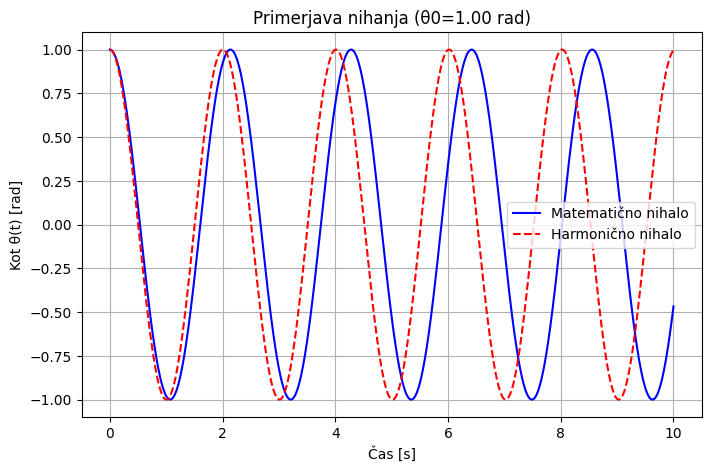

In [7]:
primerjaj_nihali(theta0=1.0, l=1.0)

### Graf \(T(E)\): odvisnost nihajnega časa matematičnega nihala od energije

Iz grafa opazimo, da je nihajni čas narašča z naraščanjem energije sistema

**Komentar k grafu \(T(E)\)**

- Za vsako začetno stanje s kotom \(\theta_0\) (in \(\omega_0=0\)) izračunamo energijo
  \[
  E = g l (1 - \cos\theta_0),
  \]
  ter numerično oceno periode \(T\) z iskanjem prvih dveh lokalnih maksimumov v časovni seriji \(\theta(t)\).
- Graf prikazuje \(T\) kot funkcijo \(E\). Vidimo, da se pri nizkih energijah \(T\) približuje linearni vrednosti
  \(T_0 = 2\pi\sqrt{l/g}\), medtem ko za večje energije \(T\) narašča — to pomeni, da nelinearnost poveča nihajni čas.
- Numerični postopek:
  - Rešimo sistem z DOPRI5 (funkcija `solve_dopri5`) do dovolj velikega časa (tako da ujame vsaj dva vrhova).
  - Iz časovne serije poiščemo prva dva vrha in vzamemo razliko časov kot oceno periode.
- Opozorilo: pri zelo velikih kotih (bližje \(\pi\)) je treba paziti na izbor `max_t` in `h`, da bomo našli vrhove; v nekaterih primerih bo metoda vrnila `NaN`, če ni zaznala dveh vrhov v izbranem intervalu.


...Risanje grafa nihajnega casa v odvisnosti od energije...


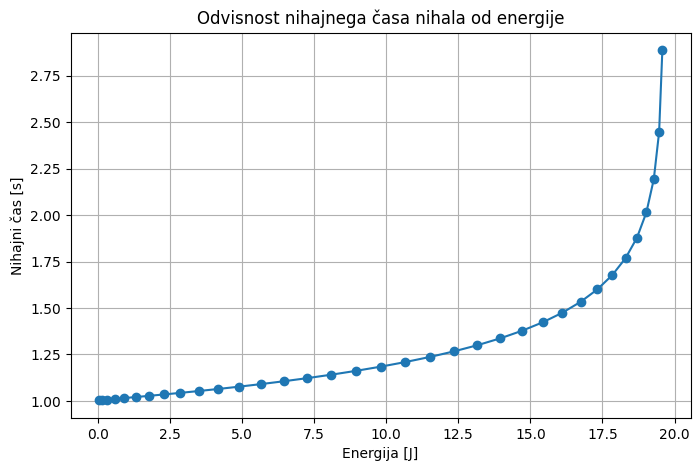

In [ ]:
from runtests import graf

# Odvisnost nihajnega časa nihala od energije, od 5° do 175°
graf()

## Zaključek

- Matematično in harmonično nihalo se za majhne začetne kote praktično ujemata.
- Pri večjih začetnih kotih pa matematično nihalo doživi podaljšanje periode - to se jasno pokaže na grafu \(T(E)\), kjer je nihajni čas monotono naraščajoč z energijo sistema.
- Amplituda nihanja ostaja enaka (sistem je nedušen), kar pomeni, da se sprememba pokaže predvsem v **periodi**, ne v izgubi amplitude.
